# Лабораторная работа №2. Моделирование непрерывной случайной величины
**Вариант 5**

**Плотность распределения:** $f(x) = 0.2 \exp\{-x/5\}$
**Область задания:** $[0; \infty)$

### 1. Теоретический анализ
Заданная функция плотности соответствует **Показательному (экспоненциальному) распределению** $f(x) = \lambda e^{-\lambda x}$ с параметром $\lambda = 0.2$.

**Теоретические характеристики:**
* Математическое ожидание: $M[X] = \frac{1}{\lambda} = \frac{1}{0.2} = 5$
* Дисперсия: $D[X] = \frac{1}{\lambda^2} = \frac{1}{0.2^2} = 25$
* Функция распределения: $F(x) = 1 - e^{-\lambda x} = 1 - e^{-0.2x}$

**Алгоритм моделирования:**
Для генерации используется метод обратной функции. 
Если $\alpha$ — базовая случайная величина (БСВ) на интервале $[0,1]$, то искомая случайная величина генерируется по формуле:
$$ \xi = -\frac{1}{\lambda} \ln \alpha = -5 \ln \alpha $$

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats

# ==========================================
# 1. ПАРАМЕТРЫ И ГЕНЕРАЦИЯ ВЫБОРКИ
# ==========================================
LAMBDA = 0.2       # Параметр распределения
SAMPLE_SIZE = 1000 # Объем выборки

# Теоретические значения
theor_mean = 1 / LAMBDA
theor_var = 1 / (LAMBDA**2)

print(f"--- ТЕОРЕТИЧЕСКИЕ ДАННЫЕ ---")
print(f"M[X] = {theor_mean}")
print(f"D[X] = {theor_var}")
print("-" * 40)

def generate_exponential(n, lam):
    """
    Генератор показательного распределения методом обратной функции.
    xi = -(1/lambda) * ln(alpha)
    """
    # Генерируем БСВ alpha от 0 до 1 (исключая точный 0 для логарифма)
    alpha = np.random.uniform(1e-10, 1.0, n)
    xi = -(1 / lam) * np.log(alpha)
    return xi

# Создаем выборку и помещаем в DataFrame
sample = generate_exponential(SAMPLE_SIZE, LAMBDA)
df = pd.DataFrame({'value': sample})

--- ТЕОРЕТИЧЕСКИЕ ДАННЫЕ ---
M[X] = 5.0
D[X] = 24.999999999999996
----------------------------------------


### 2. Точечные оценки и Доверительный интервал
* **Доверительный интервал для мат. ожидания** вычисляется с использованием нормального распределения (т.к. выборка большая $n=1000$, по Центральной предельной теореме выборочное среднее распределено нормально). Формула:
$$ \bar{x} \pm t_{\gamma} \frac{s}{\sqrt{n}} $$

In [3]:
# ==========================================
# 2. ОЦЕНКИ И ДОВЕРИТЕЛЬНЫЙ ИНТЕРВАЛ
# ==========================================
sample_mean = df['value'].mean()
sample_var = df['value'].var(ddof=1) # ddof=1 для несмещенной оценки
sample_std = df['value'].std(ddof=1)

print(f"Выборочное M[X]: {sample_mean:.4f} (Ошибка: {abs(sample_mean - theor_mean):.4f})")
print(f"Выборочная D[X]: {sample_var:.4f} (Ошибка: {abs(sample_var - theor_var):.4f})")

# Доверительный интервал (уровень надежности gamma = 0.95, значит alpha = 0.05)
# Квантиль нормального распределения для 95% интервала ~ 1.96
gamma = 0.95
t_gamma = stats.norm.ppf((1 + gamma) / 2) 

margin_of_error = t_gamma * (sample_std / np.sqrt(SAMPLE_SIZE))
ci_lower = sample_mean - margin_of_error
ci_upper = sample_mean + margin_of_error

print("-" * 40)
print(f"95% Доверительный интервал для мат. ожидания:")
print(f"[{ci_lower:.4f} ; {ci_upper:.4f}]")
if ci_lower <= theor_mean <= ci_upper:
    print("ВЫВОД: Теоретическое мат. ожидание попадает в доверительный интервал.")
else:
    print("ВЫВОД: Теоретическое мат. ожидание НЕ попадает в интервал.")

Выборочное M[X]: 5.2000 (Ошибка: 0.2000)
Выборочная D[X]: 28.4184 (Ошибка: 3.4184)
----------------------------------------
95% Доверительный интервал для мат. ожидания:
[4.8696 ; 5.5304]
ВЫВОД: Теоретическое мат. ожидание попадает в доверительный интервал.


### 3. Проверка гипотезы по критерию Пирсона ($\chi^2$)
Для непрерывной случайной величины критерий Хи-квадрат:
1. Всю ось от $min$ до $max$ значений разбивают на $k$ интервалов. Количество интервалов рассчитывают по формуле Стерджеса: $k \approx 1 + 3.322 \lg n$.
2. Считают, сколько чисел попало в каждый интервал (**Наблюдаемые частоты**).
3. Интегрируя функцию плотности на каждом интервале, находят вероятность попадания в него, и умножают на $n$ (**Ожидаемые частоты**).
4. Вычисляют $\chi^2$: $\sum \frac{(O - E)^2}{E}$.

In [7]:
# ==========================================
# 3. КРИТЕРИЙ ПИРСОНА (ХИ-КВАДРАТ)
# ==========================================
# Определяем количество интервалов (Формула Стерджеса)
k_intervals = int(np.ceil(1 + 3.322 * np.log10(SAMPLE_SIZE)))
print(f"Количество интервалов разбиения: {k_intervals}")

# Разбиваем данные на интервалы (bins)
# observed_freq - сколько реально чисел попало в каждый интервал
# bin_edges - границы этих интервалов
observed_freq, bin_edges = np.histogram(sample, bins=k_intervals)

# Вычисляем теоретические вероятности попадания в каждый интервал
# Формула: P(a < X < b) = F(b) - F(a) = exp(-lambda * a) - exp(-lambda * b)
expected_freq = []
for i in range(k_intervals):
    a = bin_edges[i]
    b = bin_edges[i+1]
    
    # Для последнего интервала правая граница должна уходить в бесконечность,
    # чтобы покрыть весь оставшийся "хвост" распределения.
    # Вероятность P(X >= a) = 1 - F(a) = exp(-lambda * a)
    if i == k_intervals - 1:
        prob = np.exp(-LAMBDA * a) 
    else:
        prob = np.exp(-LAMBDA * a) - np.exp(-LAMBDA * b)
        
    expected_freq.append(prob * SAMPLE_SIZE)

expected_freq = np.array(expected_freq)

# Проблема "хвоста": по правилам Хи-квадрат ожидаемая частота должна быть >= 5.
# При N=1000 по формуле Стерджеса получается около 11 интервалов.
# Для показательного распределения в хвосте обычно остается достаточное 
# число элементов, поэтому мы считаем X^2 напрямую по всем интервалам.

chi2_stat = np.sum((observed_freq - expected_freq)**2 / expected_freq)

# Степени свободы: (количество интервалов) - 1 - (количество оцениваемых параметров)
# Параметр lambda нам дан по варианту (0.2), мы его не оценивали по выборке (не искали по формуле),
# поэтому вычитаем только 1.
df_chi = k_intervals - 1
chi2_crit = stats.chi2.ppf(0.95, df_chi)

print(f"Статистика Пирсона X^2: {chi2_stat:.4f}")
print(f"Критическое значение X^2: {chi2_crit:.4f}")

if chi2_stat < chi2_crit:
    print("ВЫВОД: Гипотеза ПРИНИМАЕТСЯ по критерию Пирсона. (Генератор работает верно)")
else:
    print("ВЫВОД: Гипотеза ОТВЕРГАЕТСЯ по критерию Пирсона.")

Количество интервалов разбиения: 11
Статистика Пирсона X^2: 13.1087
Критическое значение X^2: 18.3070
ВЫВОД: Гипотеза ПРИНИМАЕТСЯ по критерию Пирсона. (Генератор работает верно)


### 4. Проверка гипотезы по критерию Мизеса ($\omega^2$)
Критерий Мизеса измеряет квадратичное отклонение эмпирической функции распределения $F_n(x)$ от теоретической $F_0(x)$.
В отличие от $\chi^2$, он не требует искусственного группирования данных в интервалы.

Формула статистики критерия:
$$ \omega_n^2 = n \int_{-\infty}^{\infty}[F_n(x) - F_0(x)]^2 dF_0(x) $$

На практике (и внутри библиотек Python) вычисление интеграла заменяется удобной суммой по вариационному ряду (отсортированной выборке):
$$ \omega^2 = \frac{1}{12n} + \sum_{i=1}^{n} \left( F_0(X_{(i)}) - \frac{2i - 1}{2n} \right)^2 $$

Воспользуемся встроенной функцией `cramervonmises` из библиотеки `scipy.stats`.

In [8]:
# ==========================================
# 4. КРИТЕРИЙ МИЗЕСА (w^2)
# ==========================================
# scipy.stats.cramervonmises проверяет совпадение выборки с заданным распределением
# 'expon' - экспоненциальное. Параметры: loc=0, scale = 1/lambda = 5

mises_result = stats.cramervonmises(sample, 'expon', args=(0, 1/LAMBDA))

mises_stat = mises_result.statistic
p_value = mises_result.pvalue

print(f"Статистика Мизеса w^2: {mises_stat:.4f}")
print(f"p-value: {p_value:.4f}")

# Если p-value > 0.05, мы не можем отвергнуть гипотезу
if p_value > 0.05:
    print("ВЫВОД: Гипотеза ПРИНИМАЕТСЯ по критерию Мизеса (данные соответствуют распределению).")
else:
    print("ВЫВОД: Гипотеза ОТВЕРГАЕТСЯ по критерию Мизеса.")

Статистика Мизеса w^2: 0.0816
p-value: 0.6828
ВЫВОД: Гипотеза ПРИНИМАЕТСЯ по критерию Мизеса (данные соответствуют распределению).


### 5. Построение графиков
Накладываю эмпирическую плотность на график заданной функции плотности $f(x) = 0.2 e^{-x/5}$.

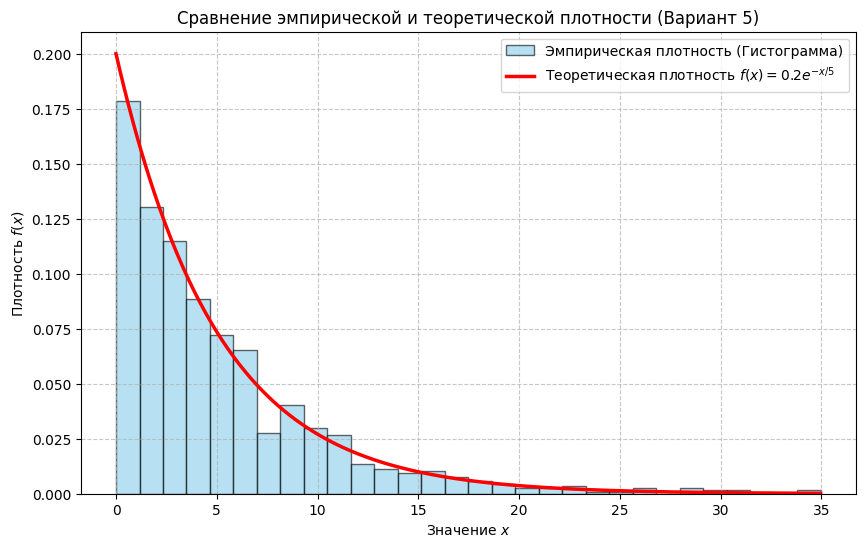

In [9]:
# ==========================================
# 5. ГРАФИКИ ПЛОТНОСТЕЙ РАСПРЕДЕЛЕНИЯ
# ==========================================
plt.figure(figsize=(10, 6))

# Эмпирическая плотность (Гистограмма)
# Параметр density=True делает так, чтобы площадь под гистограммой была равна 1 (плотность)
plt.hist(sample, bins=30, density=True, alpha=0.6, color='skyblue', edgecolor='black', label='Эмпирическая плотность (Гистограмма)')

# Теоретическая плотность
# Создаем плавную ось X от 0 до максимума в выборке
x_vals = np.linspace(0, sample.max(), 500)
# f(x) = 0.2 * exp(-x/5)
y_vals = LAMBDA * np.exp(-LAMBDA * x_vals)

plt.plot(x_vals, y_vals, 'r-', linewidth=2.5, label='Теоретическая плотность $f(x)=0.2e^{-x/5}$')

plt.title('Сравнение эмпирической и теоретической плотности (Вариант 5)')
plt.xlabel('Значение $x$')
plt.ylabel('Плотность $f(x)$')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()